<a href="https://colab.research.google.com/github/haujla2391/CSCI-4170/blob/main/CSCI4170_hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import kagglehub

In [ ]:
device = torch.device('cpu')
if torch.cuda.is_available():
  device = torch.device('cuda')
torch.set_default_device(device)

# Task 2

Dataset: https://www.kaggle.com/datasets/varpit94/tesla-stock-data-updated-till-28jun2021

This dataset contains Tesla stock prices from 2010 to 2022.

You need a sequence model to solve this problem because of the fact that a stock current price depends on it's price before and to predict it, you need data on the stock over the last few months. Normal models won't capture the importance of sequences as much as a RNN or other sequence model.

In [ ]:
path = kagglehub.dataset_download("varpit94/tesla-stock-data-updated-till-28jun2021")

Using Colab cache for faster access to the 'tesla-stock-data-updated-till-28jun2021' dataset.


#### Feature Engineering based on Quant stats

In [ ]:
def get_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

In [ ]:
files = os.listdir(path)
df = pd.read_csv(os.path.join(path, files[0]))

# convert the date section to a time object
df["Date"] = pd.to_datetime(df["Date"])

# Create a new column for daily percentage change
df['Return'] = df['Adj Close'].pct_change()

# 1. RSI (Relative Strength Index) - Is it overbought?
df['RSI'] = get_rsi(df['Adj Close'])
# 2. Moving Average Gap - Is it far from its 20-day trend?
df['MA20_Gap'] = df['Adj Close'] / df['Adj Close'].rolling(window=20).mean()

# (Price 5 days from now / Price today) - 1
df['Target_Next_5_Days'] = df['Adj Close'].shift(-5) / df['Adj Close'] - 1

# 2. Add Volatility (Helping the model see 'Risk')
df['Volatility'] = df['Return'].rolling(window=7).std()

df.dropna(inplace=True) # Remove the first row which becomes NaN

# Sort by the date if not already
df = df.sort_values("Date").reset_index(drop=True)
# Remove date out and put it as the rows
df.set_index("Date", inplace=True)

print(df.shape)
print(df.info())

num_duplicates = df.duplicated().sum()
print("Duplicate rows: ", num_duplicates)

missing_vals = df.isna().sum().sum()
print("Missing values: ", missing_vals)


(2932, 11)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2932 entries, 2010-07-27 to 2022-03-17
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Open                2932 non-null   float64
 1   High                2932 non-null   float64
 2   Low                 2932 non-null   float64
 3   Close               2932 non-null   float64
 4   Adj Close           2932 non-null   float64
 5   Volume              2932 non-null   int64  
 6   Return              2932 non-null   float64
 7   RSI                 2932 non-null   float64
 8   MA20_Gap            2932 non-null   float64
 9   Target_Next_5_Days  2932 non-null   float64
 10  Volatility          2932 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 274.9 KB
None
Duplicate rows:  0
Missing values:  0


#### EDA

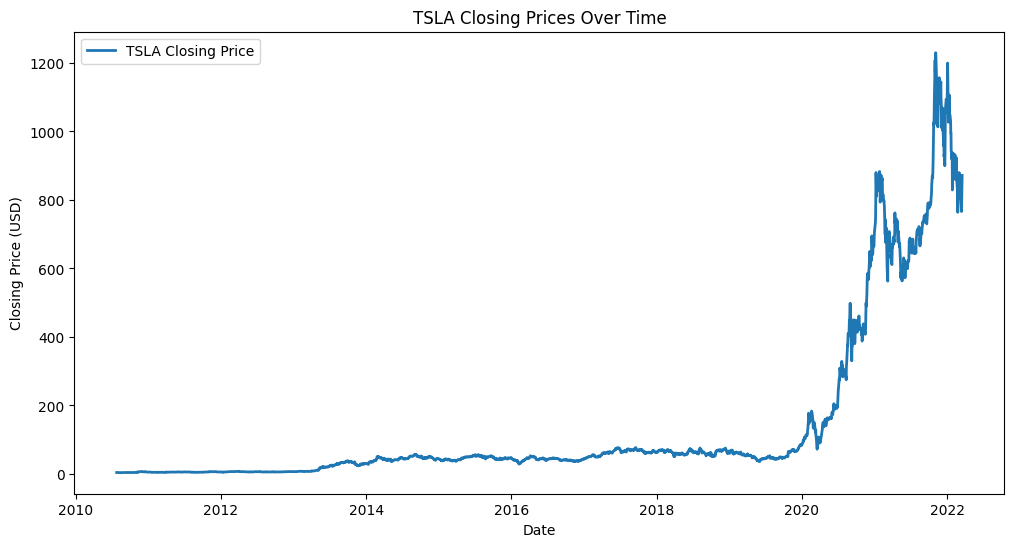

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label=f'TSLA Closing Price', linewidth=2)
plt.title(f'TSLA Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()

#### Split data into windows

In [ ]:
# 80-10-10 split
split_idx = int(len(df) * 0.8)
val_split_idx = int(len(df) * 0.9)
train_df, val_df, test_df = df.iloc[:split_idx], df.iloc[split_idx:val_split_idx], df.iloc[val_split_idx:]

# scale between 0 and 1
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(train_df.drop(['Close', 'Target_Next_5_Days'], axis=1))
y_train_scaled = y_scaler.fit_transform(train_df[['Target_Next_5_Days']])

# scale using same scaler as train
X_val_scaled = x_scaler.transform(val_df.drop(['Close', 'Target_Next_5_Days'], axis=1))
y_val_scaled = y_scaler.transform(val_df[['Target_Next_5_Days']])

# scale using same scaler as train
X_test_scaled = x_scaler.transform(test_df.drop(['Close', 'Target_Next_5_Days'], axis=1))
y_test_scaled = y_scaler.transform(test_df[['Target_Next_5_Days']])

# Create a window
days_window = 60
X_train, y_train = [], []
for x in range(days_window, len(X_train_scaled)):
  # 0-60 rows, then 1-61, etc. Rows are the dates in order
  X_train.append(X_train_scaled[x-days_window:x, :])    # don't have to drop adj close since this is not including current time x
  y_train.append(y_train_scaled[x])

X_train, y_train = np.array(X_train), np.array(y_train)

# val data
X_val, y_val = [], []
for x in range(days_window, len(X_val_scaled)):
  X_val.append(X_val_scaled[x-days_window:x, :])
  y_val.append(y_val_scaled[x])

X_val, y_val = np.array(X_val), np.array(y_val)

# test data
X_test, y_test = [], []
for x in range(days_window, len(X_test_scaled)):
  X_test.append(X_test_scaled[x-days_window:x, :])
  y_test.append(y_test_scaled[x])

X_test, y_test = np.array(X_test), np.array(y_test)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(2285, 60, 9)
(233, 60, 9)
(234, 60, 9)


## Part 1: Model Definition

In [ ]:
class MyRNN(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, output_size):
    super().__init__()
    self.num_layers = num_layers
    self.hidden_size = hidden_size

    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
    # input shape: (batch_size, window, features)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):

    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)   # hidden state before first input (0)

    out, _ = self.rnn(x, h0)
    # output shape: batch_size, window, hidden_size, where a point is the weight learned (could be 32 weights at each window)
    out = out[:, -1, :]   # take last window output for all points in batch
    out = self.fc(out)
    return out

#### Hyperparameters

In [ ]:
batch_size = 32
num_epochs = 20
learning_rate = 0.00001
weight_decay = 1e-4

#### Get data loaders

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

#### Model and Loss

In [ ]:
model = MyRNN(input_size=9, hidden_size=8, num_layers=2, output_size=1).to(device)
# we have 2 hidden layers here, (32, 60, 5) -> (32, 60, 32) -> (32, 60, 32) where 32 is the weights of the refined features
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.MSELoss()
print(model)

MyRNN(
  (rnn): RNN(9, 8, num_layers=2, batch_first=True)
  (fc): Linear(in_features=8, out_features=1, bias=True)
)


#### Training

In [ ]:
# train
def train_val(model, train_loader, val_loader, num_epochs):
  train_losses, val_losses = [], []

  for epoch in range(num_epochs):
    train_loss = 0.0

    model.train()
    for inputs, labels in train_loader:
      inputs = inputs.to(device)
      labels = labels.to(device).view(-1, 1)

      optimizer.zero_grad()

      outputs = model(inputs) # forward
      loss = criterion(outputs, labels)

      loss.backward()

      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()

      train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # validation
    val_loss = 0.0

    model.eval()
    with torch.no_grad():
      for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).view(-1, 1)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {(epoch + 1)}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

  plt.plot(train_losses, label='Train Loss')
  plt.plot(val_losses, label='Val Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.title('Training and Validation Loss')
  plt.show()

Epoch 1: Train Loss: 1.0889, Val Loss: 3.4222
Epoch 2: Train Loss: 1.0860, Val Loss: 3.4265
Epoch 3: Train Loss: 1.0883, Val Loss: 3.4308
Epoch 4: Train Loss: 1.0752, Val Loss: 3.4359
Epoch 5: Train Loss: 1.0765, Val Loss: 3.4410
Epoch 6: Train Loss: 1.0646, Val Loss: 3.4467
Epoch 7: Train Loss: 1.0601, Val Loss: 3.4527
Epoch 8: Train Loss: 1.0592, Val Loss: 3.4588
Epoch 9: Train Loss: 1.0522, Val Loss: 3.4651
Epoch 10: Train Loss: 1.0602, Val Loss: 3.4713
Epoch 11: Train Loss: 1.0453, Val Loss: 3.4776
Epoch 12: Train Loss: 1.0433, Val Loss: 3.4839
Epoch 13: Train Loss: 1.0423, Val Loss: 3.4908
Epoch 14: Train Loss: 1.0407, Val Loss: 3.4978
Epoch 15: Train Loss: 1.0379, Val Loss: 3.5043
Epoch 16: Train Loss: 1.0425, Val Loss: 3.5118
Epoch 17: Train Loss: 1.0293, Val Loss: 3.5193
Epoch 18: Train Loss: 1.0629, Val Loss: 3.5266
Epoch 19: Train Loss: 1.0286, Val Loss: 3.5329
Epoch 20: Train Loss: 1.0251, Val Loss: 3.5402


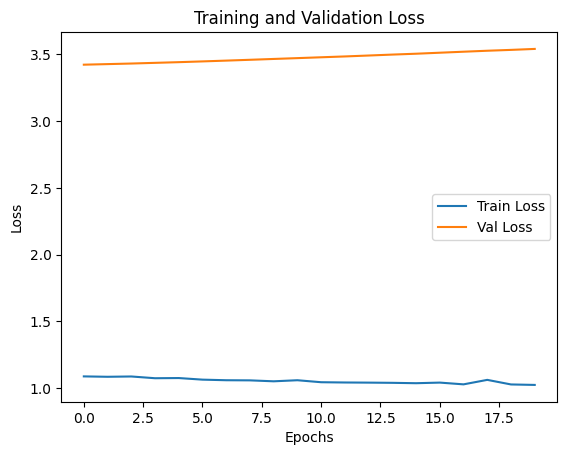

In [ ]:
train_val(model, train_loader, val_loader, num_epochs)

#### Test

In [ ]:
def test(model, test_loader):
  test_loss = 0.0
  correct, total = 0, 0

  model.eval()
  with torch.no_grad():
    for inputs, labels in test_loader:
      inputs = inputs.to(device)
      labels = labels.to(device).view(-1, 1)

      outputs = model(inputs)
      # Check if the model is just saying the same thing every time
      loss = criterion(outputs, labels)

      test_loss += loss.item()

      # threshold for checking
      zero_return_scaled = y_scaler.transform([[0]])[0][0]

      predicted = (outputs > zero_return_scaled)
      actual = (labels > zero_return_scaled)
      correct += (predicted == actual).sum().item()
      total += labels.size(0)

  avg_test_loss = test_loss / len(test_loader)
  accuracy = correct / total * 100

  print(f"Test Loss: {avg_test_loss:.4f}")
  print(f"Test Accuracy: {accuracy:.2f}%")

In [ ]:
test(model, test_loader)

Test Loss: 1.3636
Test Accuracy: 53.42%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

## Part 2: LSTM and GRU

In [ ]:
class MyLSTM(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
    super().__init__()
    self.num_layers = num_layers
    self.hidden_size = hidden_size

    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
    # input shape: (batch_size, window, features)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):

    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)   # hidden state before first input (0)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device) # cell state

    out, _ = self.lstm(x, (h0, c0))
    # output shape: batch_size, window, hidden_size, where a point is the weight learned (could be 32 weights at each window)
    out = out[:, -1, :]   # take last window output for all points in batch
    out = self.fc(out)
    return out

In [ ]:
model = MyLSTM(input_size=9, hidden_size=8, num_layers=2, output_size=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.MSELoss()
print(model)

MyLSTM(
  (lstm): LSTM(9, 8, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=8, out_features=1, bias=True)
)


Epoch 1: Train Loss: 1.0785, Val Loss: 3.4293
Epoch 2: Train Loss: 1.0772, Val Loss: 3.4319
Epoch 3: Train Loss: 1.0728, Val Loss: 3.4345
Epoch 4: Train Loss: 1.0764, Val Loss: 3.4374
Epoch 5: Train Loss: 1.0745, Val Loss: 3.4403
Epoch 6: Train Loss: 1.0764, Val Loss: 3.4436
Epoch 7: Train Loss: 1.0659, Val Loss: 3.4468
Epoch 8: Train Loss: 1.0700, Val Loss: 3.4498
Epoch 9: Train Loss: 1.0716, Val Loss: 3.4528
Epoch 10: Train Loss: 1.0639, Val Loss: 3.4552
Epoch 11: Train Loss: 1.0580, Val Loss: 3.4578
Epoch 12: Train Loss: 1.0619, Val Loss: 3.4602
Epoch 13: Train Loss: 1.0625, Val Loss: 3.4627
Epoch 14: Train Loss: 1.0677, Val Loss: 3.4650
Epoch 15: Train Loss: 1.0593, Val Loss: 3.4674
Epoch 16: Train Loss: 1.0565, Val Loss: 3.4699
Epoch 17: Train Loss: 1.0507, Val Loss: 3.4723
Epoch 18: Train Loss: 1.0823, Val Loss: 3.4749
Epoch 19: Train Loss: 1.0535, Val Loss: 3.4773
Epoch 20: Train Loss: 1.0482, Val Loss: 3.4798


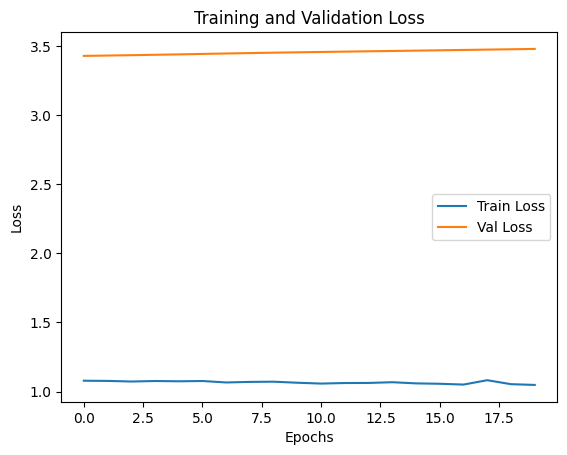

Test Loss: 1.3659
Test Accuracy: 53.42%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
train_val(model, train_loader, val_loader, num_epochs)
test(model, test_loader)

In [ ]:
class MyGRU(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
    super().__init__()
    self.num_layers = num_layers
    self.hidden_size = hidden_size

    self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
    # input shape: (batch_size, window, features)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):

    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)   # hidden state before first input (0)

    out, _ = self.gru(x, h0)
    # output shape: batch_size, window, hidden_size, where a point is the weight learned (could be 32 weights at each window)
    out = out[:, -1, :]   # take last window output for all points in batch
    out = self.fc(out)
    return out

In [ ]:
model = MyGRU(input_size=9, hidden_size=8, num_layers=2, output_size=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.MSELoss()
print(model)

MyGRU(
  (gru): GRU(9, 8, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=8, out_features=1, bias=True)
)


Epoch 1: Train Loss: 1.2374, Val Loss: 4.3016
Epoch 2: Train Loss: 1.2141, Val Loss: 4.2937
Epoch 3: Train Loss: 1.2194, Val Loss: 4.2857
Epoch 4: Train Loss: 1.2099, Val Loss: 4.2786
Epoch 5: Train Loss: 1.1907, Val Loss: 4.2715
Epoch 6: Train Loss: 1.2123, Val Loss: 4.2640
Epoch 7: Train Loss: 1.1835, Val Loss: 4.2565
Epoch 8: Train Loss: 1.1798, Val Loss: 4.2489
Epoch 9: Train Loss: 1.1778, Val Loss: 4.2420
Epoch 10: Train Loss: 1.1666, Val Loss: 4.2348
Epoch 11: Train Loss: 1.1692, Val Loss: 4.2280
Epoch 12: Train Loss: 1.1526, Val Loss: 4.2210
Epoch 13: Train Loss: 1.1448, Val Loss: 4.2145
Epoch 14: Train Loss: 1.1383, Val Loss: 4.2077
Epoch 15: Train Loss: 1.1374, Val Loss: 4.2010
Epoch 16: Train Loss: 1.1330, Val Loss: 4.1950
Epoch 17: Train Loss: 1.1309, Val Loss: 4.1875
Epoch 18: Train Loss: 1.1166, Val Loss: 4.1823
Epoch 19: Train Loss: 1.1142, Val Loss: 4.1758
Epoch 20: Train Loss: 1.1298, Val Loss: 4.1691


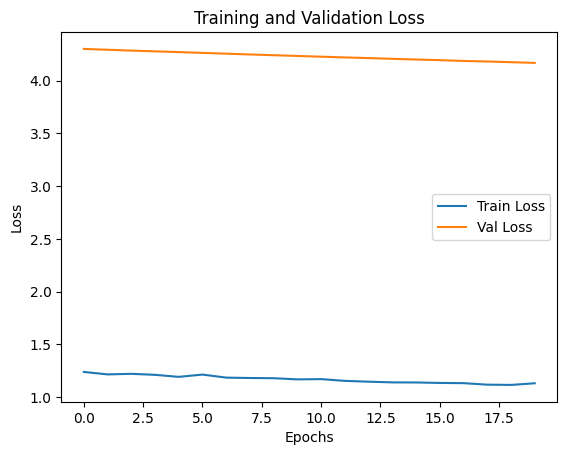

Test Loss: 1.4398
Test Accuracy: 46.58%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
train_val(model, train_loader, val_loader, num_epochs)
test(model, test_loader)

The major differences are that the RNN has 46.58% accuracy while both the LSTM and GRU get 53.42%. This means that the cell state on the LSTM allows it to remember trends and shifts from longer ago. The GRU's updating of the hidden state helps it have long term memnory. The RNN model can get to day 60 and forget the beginning of the time frame. The main takeaway is that the data is very noisy, it is a stock dataset. Our models don't have the necessary features to get higher accuracy on the dataset and perform slightly better than a coin toss using an LSTM or GRU.

## Part 3: Regular NN

Technically yes, you can but it would take a lot more feature engineering and wouldn't perform as well as our models here. This is because instead of having (32, 60, 9) we would have (32, 540). It would perform much worse because there is no sequential relationship between data. It wouldn't time step 1 vs time step 60.

# Task 3

## Part 1: Word Embeddings (FastText)

I chose FastText because it can generate embeddings for out of vocabulary words. Word2Vec and GloVe cannot and BERT can but it is a much heavier model. It can take a long time to load but also, it is better for words based on surrounding words. FastText can generate embeddings for OOV and it is lighter than BERT.

In [ ]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.1 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api

model = api.load("fasttext-wiki-news-subwords-300")

[==================================================] 100.0% 958.5/958.4MB downloaded


In [ ]:
word1 = input("Enter first word: ").strip()
word2 = input("Enter second word: ").strip()

Enter first word: happy
Enter second word: sad


In [ ]:
def get_embed(word):
  try:
    embed = model[word]
    return embed
  except KeyError:
    return None

In [ ]:
vector1 = get_embed(word1)
vector2 = get_embed(word2)

if vector1 is not None:
  print(vector1[:10], "\n----------")
else:
  print(f"'{word1}' is completely OOV and cannot be approximated")

if vector2 is not None:
  print(vector2[:10], "\n----------")
else:
  print(f"'{word2}' is completely OOV and cannot be approximated")

[ 0.022244   0.058258   0.03674   -0.025407  -0.090281   0.0081916
  0.0057731 -0.11852   -0.020007   0.011765 ] 
----------
[ 0.046758 -0.023647  0.10755   0.061935 -0.086699 -0.049102  0.030603
 -0.14441  -0.041111 -0.03215 ] 
----------


For cases where the word is out of vocab, FastText still generates embeddings based on subwords.

## Part 2: CosSim

In [ ]:
def cossim(vector1, vector2):
  return np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))

csim = cossim(vector1, vector2)
print(csim)

0.69010305


Cosine Similarity is useful in vector space because the size of a vector or its magnitude don't influence the similarity, only the direction of them is what matters.

Enter word pairs separated by commas.
Example: king queen, dog cat, apple banana

Word pairs: king queen, dog cat, apple banana
Cosine Sim: 0.7704
Cosine Sim: 0.7502
Cosine Sim: 0.5925


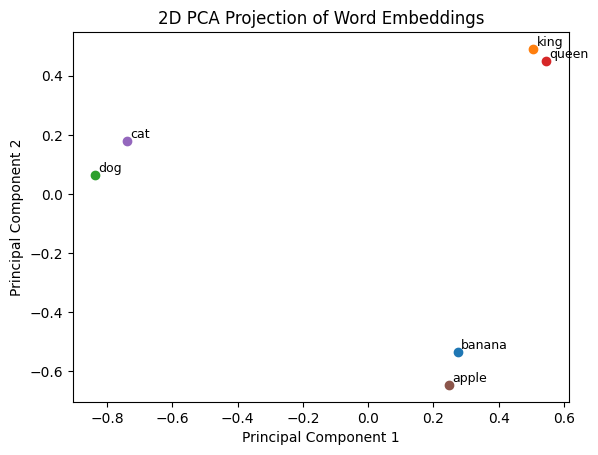

In [ ]:
print("Enter word pairs separated by commas.")
print("Example: king queen, dog cat, apple banana\n")

user_input = input("Word pairs: ")
pairs = [pair.strip().split() for pair in user_input.split(",")]

results = []
words_for_plot = set()

for pair in pairs:
  if len(pair) != 2:
      print(f"Invalid pair: {pair}")
      continue

  w1, w2 = pair
  vec1 = get_embed(w1)
  vec2 = get_embed(w2)

  if vec1 is None or vec2 is None:
      print(f"OOV detected: {w1} or {w2}")
      continue

  sim = cossim(vec1, vec2)
  print(f"Cosine Sim: {sim:.4f}")

  results.append((w1, w2, sim))
  words_for_plot.add(w1)
  words_for_plot.add(w2)

words = list(words_for_plot)
embeddings = [model[word] for word in words]

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure()
for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=9)

plt.title("2D PCA Projection of Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Part 3: Dissimilarity Metric (Euclidean Distance)

Having Euclidean distance is useful because Cosine sim just checks for direction but there can be cases where a pair can be pointing in similar directions but not be close to each other magnitude wise. This would allow us to handle this.

Paper: Mikolov et al., 2013 - Efficient Estimation of Word Representations in Vector Space (Word2Vec)

In [ ]:
def toggle(w1, w2, method="cosine"):
  v1, v2 = get_embed(w1), get_embed(w2)
  if method == "cosine":
    return cossim(v1, v2)
  elif method == "euclidean":
    return np.linalg.norm(v1 - v2)
  else:
    print("Must be either Cosine or Euclidean")

In [ ]:
def plot_ranking(reference_word, comparison_words, method):
  scores = []

  for word in comparison_words:
      score = toggle(reference_word, word, method)
      scores.append(score)

  if method == "cosine":
      sorted_pairs = sorted(zip(comparison_words, scores),
                            key=lambda x: x[1], reverse=True)
  else:
      sorted_pairs = sorted(zip(comparison_words, scores),
                            key=lambda x: x[1])

  words, sorted_scores = zip(*sorted_pairs)

  plt.figure()
  plt.bar(words, sorted_scores)
  plt.title(f"Ranking relative to '{reference_word}' using {method}")
  plt.xlabel("Words")
  plt.ylabel("Similarity" if method == "cosine" else "Distance")
  plt.xticks(rotation=45)
  plt.show()


In [ ]:
def plot_heatmap(words, method):
  matrix = np.zeros((len(words), len(words)))

  for i, w1 in enumerate(words):
      for j, w2 in enumerate(words):
          matrix[i, j] = toggle(w1, w2, method)

  plt.figure()
  plt.imshow(matrix)
  plt.colorbar()
  plt.xticks(range(len(words)), words, rotation=45)
  plt.yticks(range(len(words)), words)
  plt.title(f"{metric.capitalize()} Matrix Heatmap")
  plt.show()

Enter reference word: cat
Enter comparison words separated by commas: dog, lion, train
Choose metric ('cosine' or 'euclidean'): euclidean


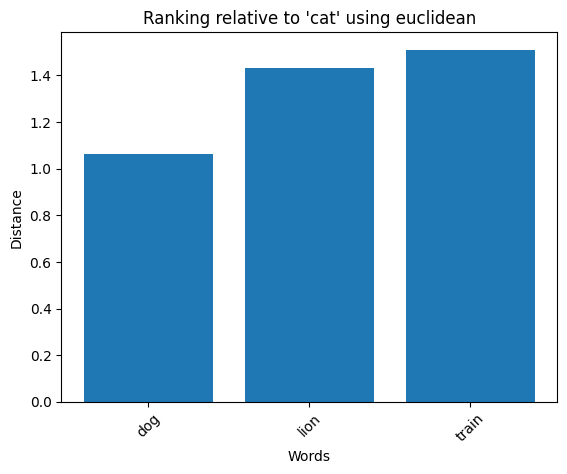

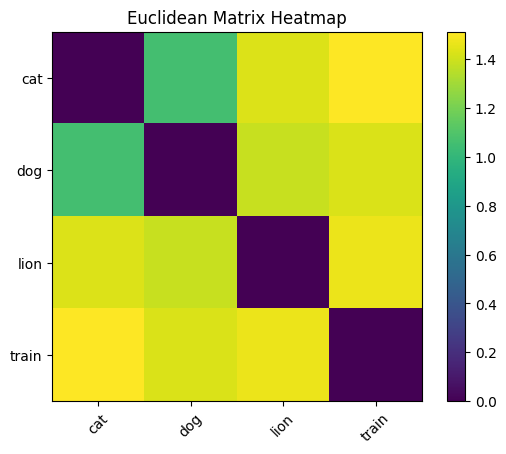

In [ ]:
reference_word = input("Enter reference word: ").strip()

comparison_input = input("Enter comparison words separated by commas: ")
comparison_words = [w.strip() for w in comparison_input.split(",")]

metric = input("Choose metric ('cosine' or 'euclidean'): ").strip().lower()

plot_ranking(reference_word, comparison_words, metric)

all_words = [reference_word] + comparison_words
plot_heatmap(all_words, metric)
